In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family']

# 데이터 읽기
golf = pd.read_csv('../datasets/decision/playing_golf.csv')

# 데이터 확인
golf

,outlook,temperature,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
6,overcast,cool,normal,True,yes
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
9,rainy,mild,normal,False,yes


In [6]:
#범주형 문자를 0또는1 컬럼으로 원핫인코딩
encoded = pd.get_dummies(golf, dtype = int)
encoded

,windy,outlook_overcast,outlook_rainy,outlook_sunny,temperature_cool,temperature_hot,temperature_mild,humidity_high,humidity_normal,play_no,play_yes
0,False,0,0,1,0,1,0,1,0,1,0
1,True,0,0,1,0,1,0,1,0,1,0
2,False,1,0,0,0,1,0,1,0,0,1
3,False,0,1,0,0,0,1,1,0,0,1
4,False,0,1,0,1,0,0,0,1,0,1
5,True,0,1,0,1,0,0,0,1,1,0
6,True,1,0,0,1,0,0,0,1,0,1
7,False,0,0,1,0,0,1,1,0,1,0
8,False,0,0,1,1,0,0,0,1,0,1
9,False,0,1,0,0,0,1,0,1,0,1


In [8]:
# 입력(X)과 목표(y) 분리
x = encoded.drop(columns=['play_no', 'play_yes'])  # 제외할 열
y = encoded['play_yes']                            # 1: 골프 침, 0: 골프 안 침

print('입력 특징:', list(x.columns))

입력 특징: ['windy', 'outlook_overcast', 'outlook_rainy', 'outlook_sunny', 'temperature_cool', 'temperature_hot', 'temperature_mild', 'humidity_high', 'humidity_normal']


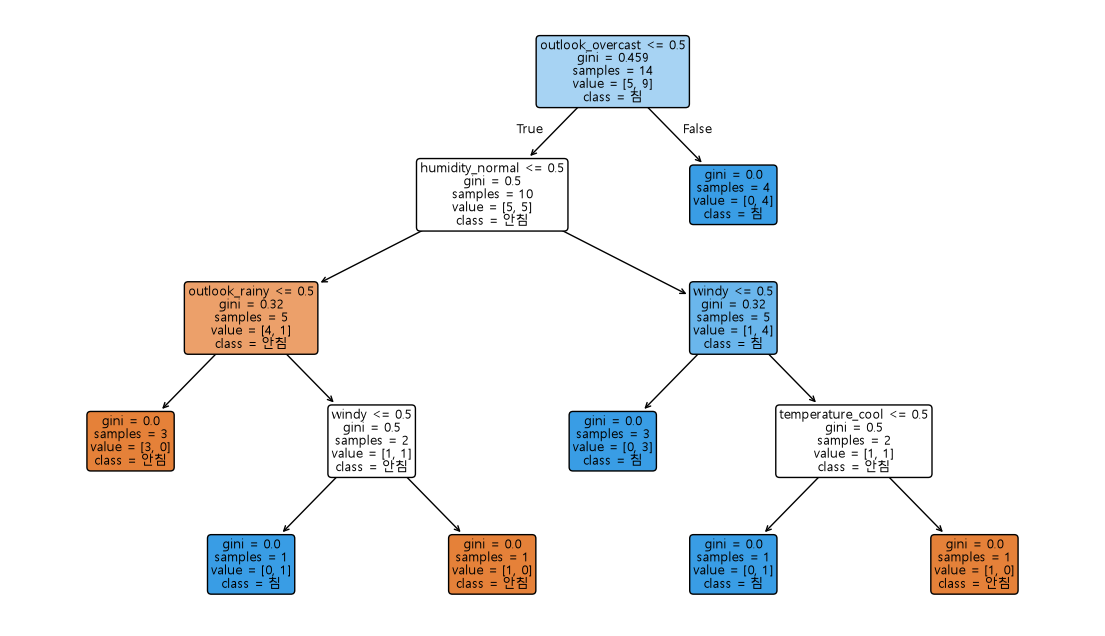

In [10]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 의사결정나무 모델 생성 및 학습
tree = DecisionTreeClassifier(random_state=0)
tree.fit(x, y)

# 트리 시각화
plt.figure(figsize=(14, 8))
plot_tree(
    tree,
    feature_names=list(x.columns),
    class_names=['안침', '침'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.show()

깊이제한없이
훈련:1.0
테스트:0.9555555555555556


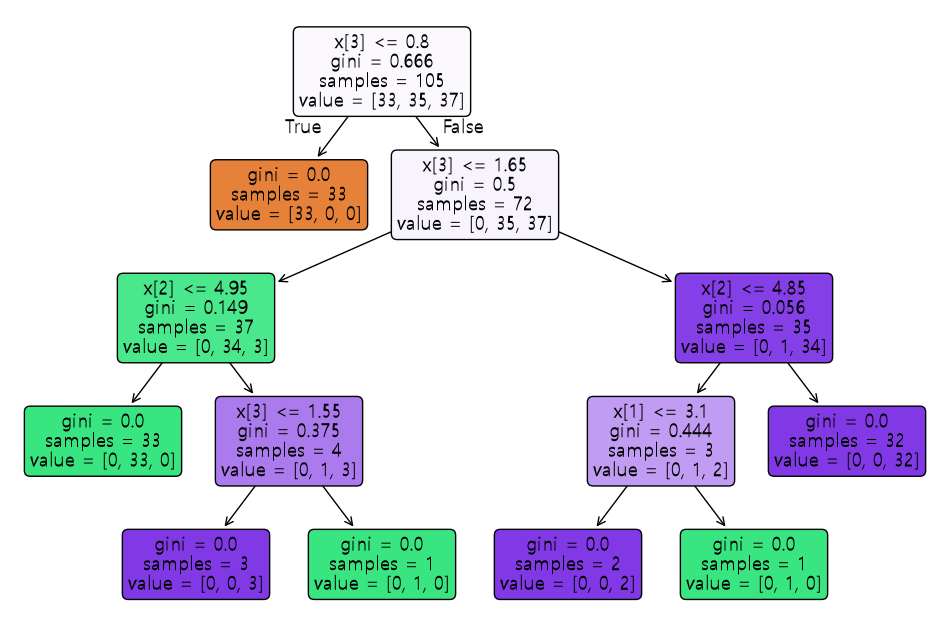

In [11]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
iris = load_iris()
x_train, x_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=2)
deep_tree = DecisionTreeClassifier(random_state=3)
deep_tree.fit(x_train, y_train)
print('깊이제한없이')
print(f'훈련:{deep_tree.score(x_train, y_train)}')
print(f'테스트:{deep_tree.score(x_test, y_test)}')
plt.figure(figsize = (12,8))
plot_tree(deep_tree, filled=True, rounded=True)
plt.show()

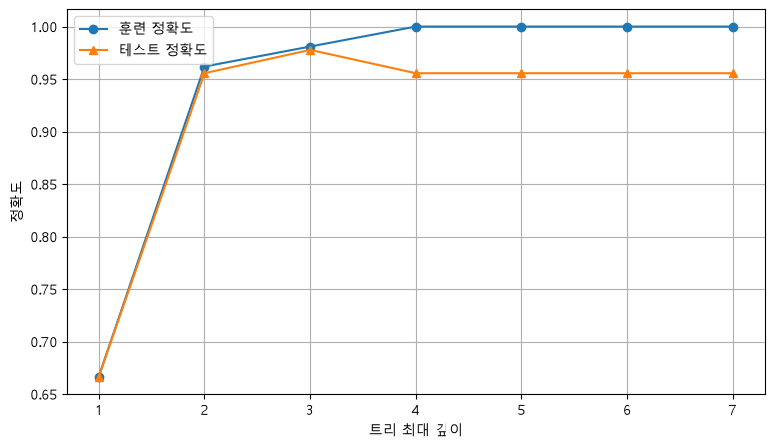

In [14]:
# 가지치기(최대 깊이)별 정확도 확인
depths = range(1, 8)
train_scores = []
test_scores = []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=3)
    m.fit(x_train, y_train)

    train_scores.append(m.score(x_train, y_train))
    test_scores.append(m.score(x_test, y_test))

plt.figure(figsize=(9, 5))
plt.plot(list(depths), train_scores, marker='o', label='훈련 정확도')
plt.plot(list(depths), test_scores, marker='^', label='테스트 정확도')

plt.xlabel('트리 최대 깊이')
plt.ylabel('정확도')
plt.legend()
plt.grid(True)
plt.show()
#테스트 정확도가 어느순간 낮아짐-훈련은 잘 되었으나 과적합된것
    

훈련 정확도: 0.981
테스트 정확도: 0.978


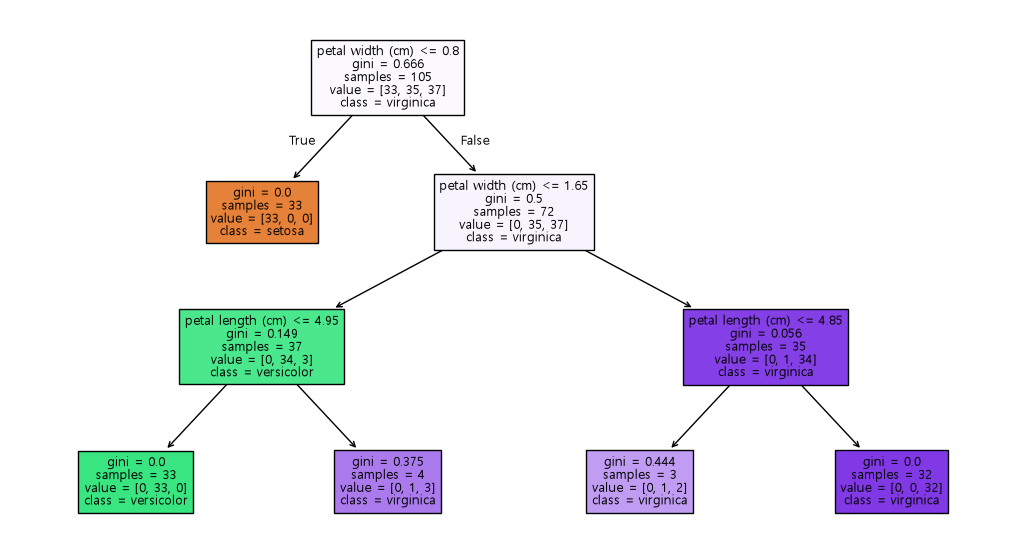

In [18]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 가지치기된 의사결정나무 생성
pruned_tree = DecisionTreeClassifier(max_depth=3, random_state=2)
pruned_tree.fit(x_train, y_train)

# 정확도 출력
print(f'훈련 정확도: {pruned_tree.score(x_train, y_train):.3f}')
print(f'테스트 정확도: {pruned_tree.score(x_test, y_test):.3f}') 

# 트리 시각화
plt.figure(figsize=(13, 7))
plot_tree(
    pruned_tree,                             # 학습이 완료된 의사결정나무 모델
    feature_names=iris.feature_names,        # 입력 특성(변수) 이름 표시
    class_names=list(iris.target_names),     # 클래스 이름(품종명) 표시
    filled=True,                             # 클래스별로 노드에 색상 채우기
    fontsize=9                               # 노드 안 글자 크기
)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

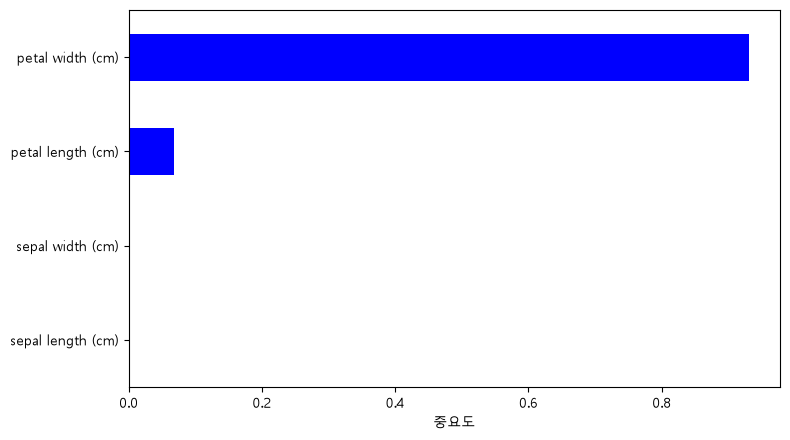

In [19]:
#특성중요도
importance = pd.Series(pruned_tree.feature_importances_, index=iris.feature_names).sort_values()
plt.figure(figsize=(8, 4.5))
importance.plot(kind='barh', color='blue')
plt.xlabel('중요도')
plt.tight_layout()
plt.show